In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [3]:
data=pd.read_csv('fertilizer_recommendation_dataset.csv')

In [4]:
data.head()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


In [5]:
data.shape

(3100, 12)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   object 
 9   Crop         3100 non-null   object 
 10  Fertilizer   3100 non-null   object 
 11  Remark       3100 non-null   object 
dtypes: float64(8), object(4)
memory usage: 290.8+ KB


In [7]:
data.describe()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon
count,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000
mean,27.271096,0.600763,111.024949,6.379775,61.278480,69.582850,69.721167,1.474325
std,9.114450,0.144947,77.151880,0.957103,10.186410,42.226712,35.304241,0.698300
min,4.011486,0.227436,-85.709593,3.448974,35.527718,-37.649739,-20.509108,-0.280560
25%,22.408505,0.493595,61.283985,5.860489,54.835715,43.039260,49.992405,0.956401
50%,26.132938,0.599520,96.485935,6.337308,59.429649,58.205269,58.710808,1.463357
75%,29.987887,0.708575,147.619401,6.899739,65.792790,86.108983,76.318626,2.003534
max,56.653592,0.972361,411.955947,9.562341,98.581039,177.314481,161.067982,3.241984


In [8]:
data.isnull().sum()

Temperature    0
Moisture       0
Rainfall       0
PH             0
Nitrogen       0
Phosphorous    0
Potassium      0
Carbon         0
Soil           0
Crop           0
Fertilizer     0
Remark         0
dtype: int64

In [9]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3095    False
3096    False
3097    False
3098    False
3099    False
Length: 3100, dtype: bool

In [10]:
data.duplicated().sum()

0

In [11]:
data.tail(20)

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
3080,25.939817,0.640556,41.361457,6.182518,53.242562,56.750004,42.370552,-0.280560,Acidic Soil,watermelon,Muriate of Potash,"High potassium content, improves fruit and flo..."
3081,25.652298,0.487124,71.254010,6.028458,35.527718,58.346650,44.191398,1.562035,Acidic Soil,watermelon,Urea,"Provides high nitrogen, ideal for rapid leafy ..."
3082,26.522854,0.634118,51.517487,6.756508,53.422678,137.217969,68.376061,1.120161,Loamy Soil,watermelon,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3083,23.340850,0.790687,67.789605,6.712979,58.686665,68.564868,159.564031,1.084381,Peaty Soil,watermelon,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."
3084,25.455188,0.781066,45.208835,8.828433,55.983922,51.661123,52.511708,1.985332,Peaty Soil,watermelon,Gypsum,"Corrects alkaline soil, adds calcium and sulfu..."
3085,21.839236,0.510456,44.505016,6.477451,57.294613,97.433084,68.179251,0.968421,Neutral Soil,watermelon,Compost,Enhances organic matter and improves soil stru...
3086,24.641678,0.605762,69.471560,7.143891,57.997108,135.130155,121.029940,0.903404,Loamy Soil,watermelon,Compost,Enhances organic matter and improves soil stru...
3087,26.208020,0.475188,66.195198,6.151351,56.130062,68.332172,59.396725,1.886535,Acidic Soil,watermelon,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3088,25.054906,0.704558,54.877138,7.060891,57.207287,137.754723,79.393255,1.379502,Loamy Soil,watermelon,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
3089,25.796935,0.436127,70.511151,6.842291,86.969711,146.366899,120.702206,0.761465,Neutral Soil,watermelon,Compost,Enhances organic matter and improves soil stru...


<Axes: ylabel='Rainfall'>

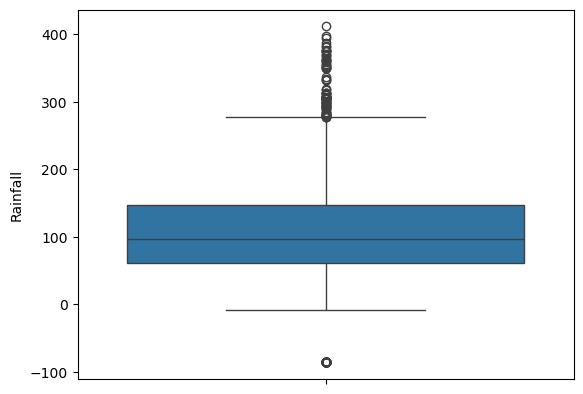

In [12]:
sns.boxplot(data['Rainfall'])

In [13]:
min_range = data["Rainfall"].mean()-(3*data["Rainfall"].std())

In [14]:
max_range = data["Rainfall"].mean()+(3*data["Rainfall"].std())

In [15]:
min_range,max_range

(-120.43069082629127, 342.48058945807514)

In [16]:
data = data[(data["Rainfall"] >= min_range) & (data["Rainfall"] <= max_range)]

<Axes: ylabel='Rainfall'>

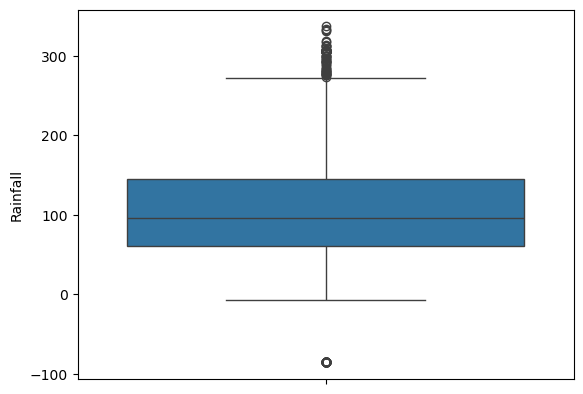

In [17]:
sns.boxplot(data["Rainfall"])

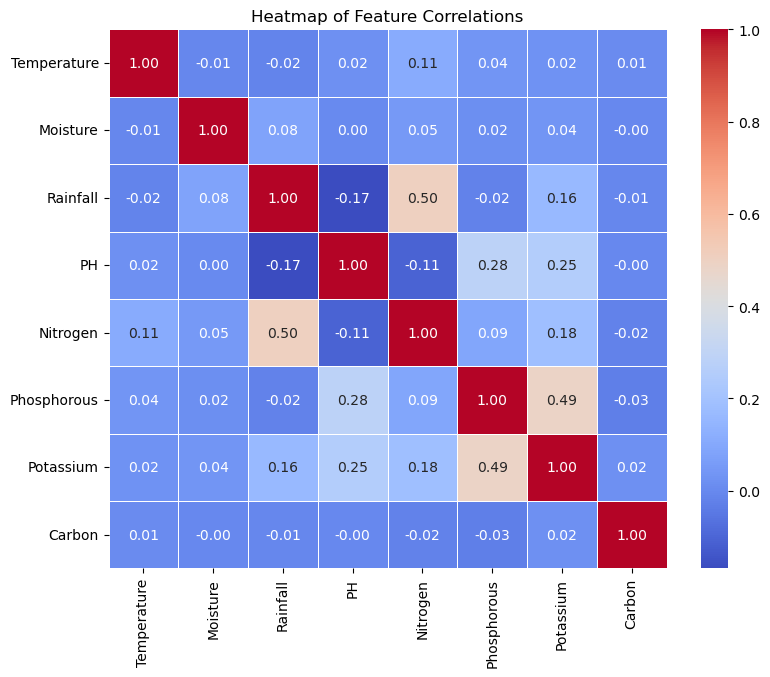

In [18]:
corr_matrix = data.select_dtypes(include=['float64']).corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Feature Correlations")
plt.show()

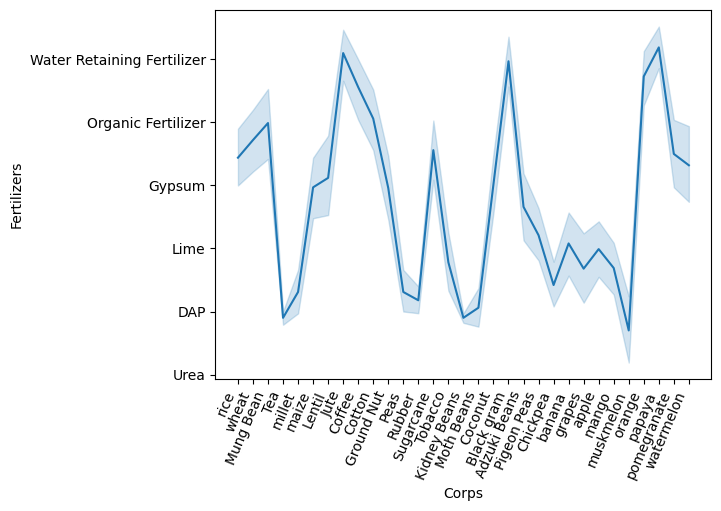

<Figure size 2000x1500 with 0 Axes>

In [19]:
plt.xticks(rotation=67, ha="right")
sns.lineplot(y="Fertilizer",x="Crop",data=data)
plt.xlabel("Corps")
plt.ylabel("Fertilizers")
plt.figure(figsize=(20,15)) 
plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder
label_encoders={}
categorical_columns = ['Soil','Crop','Fertilizer']
for col in categorical_columns:
    le=LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

In [21]:
data['Fertilizer'].tail(50)

3050    6
3051    5
3052    7
3053    1
3054    6
3055    4
3056    1
3057    6
3058    1
3059    6
3060    8
3061    6
3062    3
3063    2
3064    2
3065    6
3066    1
3067    9
3068    9
3069    9
3070    4
3071    0
3072    9
3073    1
3074    0
3075    1
3076    9
3077    4
3078    1
3079    6
3080    6
3081    8
3082    9
3083    7
3084    4
3085    1
3086    1
3087    9
3088    0
3089    1
3090    9
3091    7
3092    6
3093    0
3094    6
3095    9
3096    2
3097    9
3098    1
3099    6
Name: Fertilizer, dtype: int32

In [22]:
data['Soil'].head(20)

0     2
1     2
2     4
3     2
4     4
5     2
6     4
7     4
8     2
9     4
10    4
11    4
12    0
13    2
14    2
15    2
16    4
17    2
18    4
19    0
Name: Soil, dtype: int32

In [23]:
data['Crop'].tail(20)

3080    29
3081    29
3082    29
3083    29
3084    29
3085    29
3086    29
3087    29
3088    29
3089    29
3090    29
3091    29
3092    29
3093    29
3094    29
3095    29
3096    29
3097    29
3098    29
3099    29
Name: Crop, dtype: int32

In [24]:
x = data.drop(columns=['Fertilizer','Remark'])
y = data["Fertilizer"]

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state=42)
model1 = DecisionTreeClassifier()
model1.fit(X_train,y_train)
y_pred = model1.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy:{accuracy * 100:.2f}%')
print(classification_report(y_test,y_pred))

Accuracy:99.19%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.99      0.99      0.99        80
           2       1.00      1.00      1.00       209
           3       0.83      1.00      0.91         5
           4       0.91      1.00      0.95        10
           5       0.97      1.00      0.99        35
           6       1.00      0.99      0.99        67
           7       1.00      0.95      0.98        22
           8       1.00      0.94      0.97        33
           9       0.99      1.00      1.00       134

    accuracy                           0.99       615
   macro avg       0.97      0.99      0.98       615
weighted avg       0.99      0.99      0.99       615



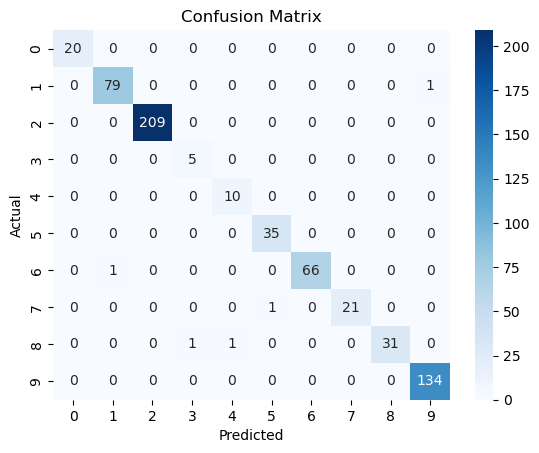

In [26]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [27]:
importances = model1.feature_importances_
feature_names = x.columns
print("Feature Importances:")
for feature, importance in zip(feature_names, importances):
    print(f'{feature}: {importance:.4f}')

Feature Importances:
Temperature: 0.0000
Moisture: 0.0981
Rainfall: 0.0000
PH: 0.1562
Nitrogen: 0.1145
Phosphorous: 0.3059
Potassium: 0.1320
Carbon: 0.1354
Soil: 0.0578
Crop: 0.0000


Accuracy: 63.58%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.00      0.00      0.00        80
           2       0.74      1.00      0.85       209
           3       0.00      0.00      0.00         5
           4       0.00      0.00      0.00        10
           5       0.00      0.00      0.00        35
           6       0.74      0.76      0.75        67
           7       0.00      0.00      0.00        22
           8       1.00      0.39      0.57        33
           9       0.47      0.89      0.62       134

    accuracy                           0.64       615
   macro avg       0.30      0.30      0.28       615
weighted avg       0.49      0.64      0.53       615



D:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


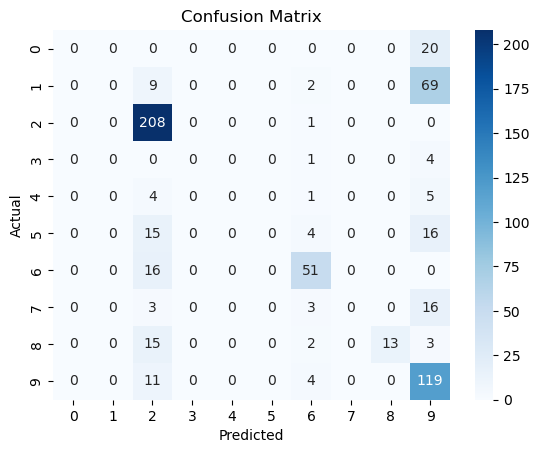

In [28]:
from sklearn.svm import SVC
x=data.drop(columns=['Fertilizer', 'Remark'])  # Drop the target variable & remarks
y=data['Fertilizer']
x_train, x_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model2 = SVC(kernel='rbf', C=1.0, gamma='scale')
model2.fit(x_train, Y_train)
Y_pred = model2.predict(x_test)
accuracy = accuracy_score(Y_test, Y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
print(classification_report(Y_test, Y_pred))
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [29]:
def recommend_fertilizer(soil, crop, nitrogen, phosphorus, potassium, temperature,carbon, moisture, pH, rainfall):
    soil_encoded = label_encoders['Soil'].transform([soil])[0]
    crop_encoded = label_encoders['Crop'].transform([crop])[0]
    input_data = np.array([[temperature, moisture, rainfall, pH, nitrogen, phosphorus, potassium,carbon, soil_encoded, crop_encoded]])
    fertilizer_code = model1.predict(input_data)[0]
    fertilizer_name = label_encoders['Fertilizer'].inverse_transform([fertilizer_code])[0]
    return fertilizer_name
def check_prediction_accuracy():
    y_pred = model1.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Model Accuracy: {accuracy * 100:.2f}%')
soil_type = 'Loamy Soil'
crop_type = 'wheat'
nitrogen = 50
phosphorus = 30
potassium = 20
carbon=1.5
temperature = 25
moisture = 60
pH = 6.5
rainfall = 200
recommended_fertilizer = recommend_fertilizer(soil_type, crop_type, nitrogen, phosphorus, potassium,carbon,temperature, moisture, pH, rainfall)
print(f'Recommended Fertilizer: {recommended_fertilizer}')
check_prediction_accuracy()

Recommended Fertilizer: Urea
Model Accuracy: 99.19%


D:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [30]:
import joblib
filename='Fertilizer_Prediction_APP'

In [31]:
joblib.dump(model1,'Fertilizer_Prediction_APP')

['Fertilizer_Prediction_APP']

In [32]:
app=joblib.load('Fertilizer_Prediction_APP')

In [38]:
array=[[20.939817,0.640556,37.361457,5.182518,42.242562,36.750004,39.370552,-0.280560,15,2]]
y_pre=app.predict(array)
y_pre

D:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([8])

In [39]:
fertilizer_name = label_encoders['Fertilizer'].inverse_transform(y_pre)
print(f'Recommended Fertilizer: {fertilizer_name[0]}')


Recommended Fertilizer: Urea


In [40]:
soil_encoded=data['Soil'].unique()
soil_name = label_encoders['Soil'].inverse_transform(soil_encoded)
print(soil_name) 

['Loamy Soil' 'Peaty Soil' 'Acidic Soil' 'Neutral Soil' 'Alkaline Soil']


In [41]:
fertilizer = data['Fertilizer'].unique()
ferti=label_encoders['Fertilizer'].inverse_transform(fertilizer)
print(ferti)

['Compost' 'Balanced NPK Fertilizer' 'Water Retaining Fertilizer'
 'Organic Fertilizer' 'Gypsum' 'Lime' 'DAP' 'Urea' 'Muriate of Potash'
 'General Purpose Fertilizer']


In [42]:
data.head(10)

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,2,28,1,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,2,28,0,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,4,28,9,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,2,28,0,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,4,28,7,"Enhances fertility naturally, ideal for peaty ..."
5,50.179845,0.227436,275.544796,8.828433,74.990641,128.631682,129.099985,0.843296,2,28,4,"Corrects alkaline soil, adds calcium and sulfu..."
6,22.386834,0.227436,292.745108,5.902666,78.814989,60.471726,66.060843,1.518379,4,28,5,Neutralizes acidic soil and improves pH balanc...
7,21.342227,0.785753,249.980185,5.692240,72.089121,42.591255,68.035609,2.410625,4,28,2,"Rich in phosphorus, essential for root develop..."
8,25.657999,0.756739,250.701012,6.614611,75.032505,118.005348,142.004742,-0.280560,2,28,1,Enhances organic matter and improves soil stru...
9,21.296925,0.783450,211.049382,6.386646,72.711484,68.352057,94.695401,2.464714,4,28,7,"Enhances fertility naturally, ideal for peaty ..."
